In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

EXP03_METRICS = "../../results/metrics/exp03_metrics.csv"   # Few-Shot
EXP02_METRICS = "../../results/metrics/exp02_metrics.csv"   # Zero-Shot
EXP01_METRICS = "../../results/metrics/exp01_metrics.csv"   # Fine-Tuning
PLOTS_DIR = "../../results/plots"

## 1. Загрузка метрик

In [7]:
# --- Few-Shot: матрица экспериментов (12 комбинаций) ---
fewshot = pd.read_csv(EXP03_METRICS)
print("Few-Shot (exp03):")
fewshot

Few-Shot (exp03):


,n_shots,strategy,f1,accuracy
0,1,random,0.430341,0.408608
1,1,central,0.479656,0.417272
2,1,diverse,0.479656,0.417272
3,3,random,0.479553,0.443823
4,3,central,0.489358,0.437395
5,3,diverse,0.486060,0.456400
6,5,random,0.489085,0.455003
7,5,central,0.482439,0.436836
8,5,diverse,0.507516,0.474008
9,10,random,0.547918,0.516769


In [9]:
# Для опорной линии берём лучший промпт по macro F1.
zeroshot_f1 = np.nan
zeroshot_name = None
exp02 = pd.read_csv(EXP02_METRICS)
f1_col = "macro_f1" if "macro_f1" in exp02.columns else "f1"
best_zs = exp02.loc[exp02[f1_col].idxmax()]
zeroshot_f1 = float(best_zs[f1_col])
if "prompt_name" in exp02.columns:
    zeroshot_name = str(best_zs["prompt_name"])
label = f"  (лучший промпт: {zeroshot_name})" if zeroshot_name else ""
print(f"Zero-Shot F1: {zeroshot_f1:.4f}{label}")

Zero-Shot F1: 0.1816  (лучший промпт: вопрос)


In [11]:
exp01 = pd.read_csv(EXP01_METRICS)
finetuning_f1 = float(exp01["macro_f1"].iloc[0])
print(f"Fine-Tuning F1: {finetuning_f1:.4f}  (модель: {exp01['model'].iloc[0]})")

Fine-Tuning F1: 0.9465  (модель: distilbert-base-uncased)


## 2. Матрица экспериментов 4×3

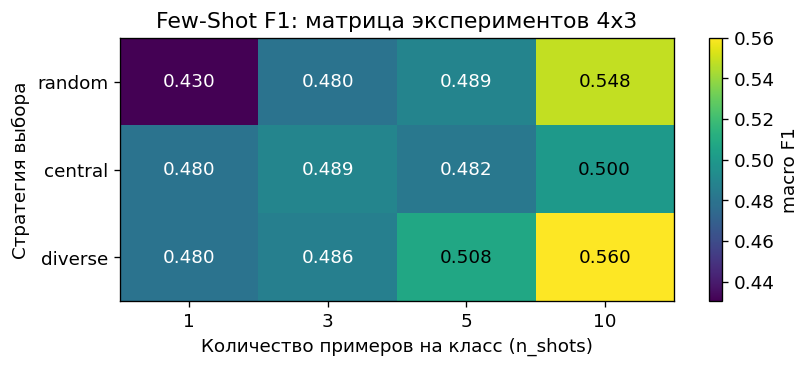

In [14]:
# pivot в матрицу strategy x n_shots
pivot_f1 = fewshot.pivot(index="strategy", columns="n_shots", values="f1")
# порядок строк фиксируем для читаемости
strategy_order = [s for s in ["random", "central", "diverse"] if s in pivot_f1.index]
pivot_f1 = pivot_f1.loc[strategy_order]

fig, ax = plt.subplots(figsize=(7, 3.2))
im = ax.imshow(pivot_f1.values, cmap="viridis", aspect="auto")

ax.set_xticks(range(len(pivot_f1.columns)))
ax.set_xticklabels(pivot_f1.columns)
ax.set_yticks(range(len(pivot_f1.index)))
ax.set_yticklabels(pivot_f1.index)
ax.set_xlabel("Количество примеров на класс (n_shots)")
ax.set_ylabel("Стратегия выбора")
ax.set_title("Few-Shot F1: матрица экспериментов 4x3")

# подписи значений в клетках
for i in range(pivot_f1.shape[0]):
    for j in range(pivot_f1.shape[1]):
        val = pivot_f1.values[i, j]
        ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                color="white" if val < pivot_f1.values.mean() else "black")

fig.colorbar(im, ax=ax, label="macro F1")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/exp03_matrix_heatmap.png", bbox_inches="tight")
plt.show()

## 3. Сравнение стратегий выбора примеров

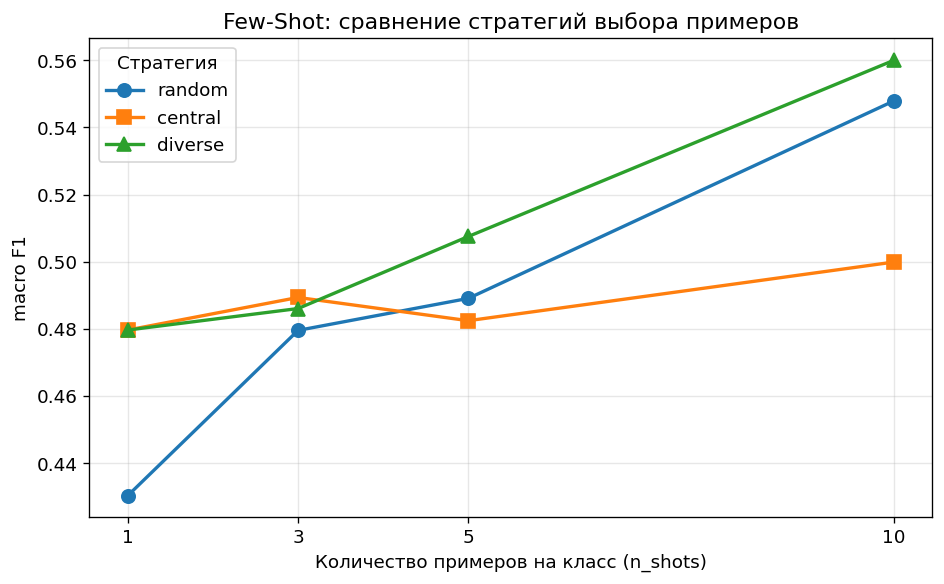

In [15]:
fig, ax = plt.subplots(figsize=(8, 5))

markers = {"random": "o", "central": "s", "diverse": "^"}
for strategy in strategy_order:
    sub = fewshot[fewshot["strategy"] == strategy].sort_values("n_shots")
    ax.plot(sub["n_shots"], sub["f1"],
            marker=markers.get(strategy, "o"), linewidth=2, markersize=8,
            label=f"{strategy}")

ax.set_xlabel("Количество примеров на класс (n_shots)")
ax.set_ylabel("macro F1")
ax.set_title("Few-Shot: сравнение стратегий выбора примеров")
ax.set_xticks(sorted(fewshot["n_shots"].unique()))
ax.grid(alpha=0.3)
ax.legend(title="Стратегия")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/exp03_strategies_comparison.png", bbox_inches="tight")
plt.show()

## 4. Quality (F1) vs. Number of Examples

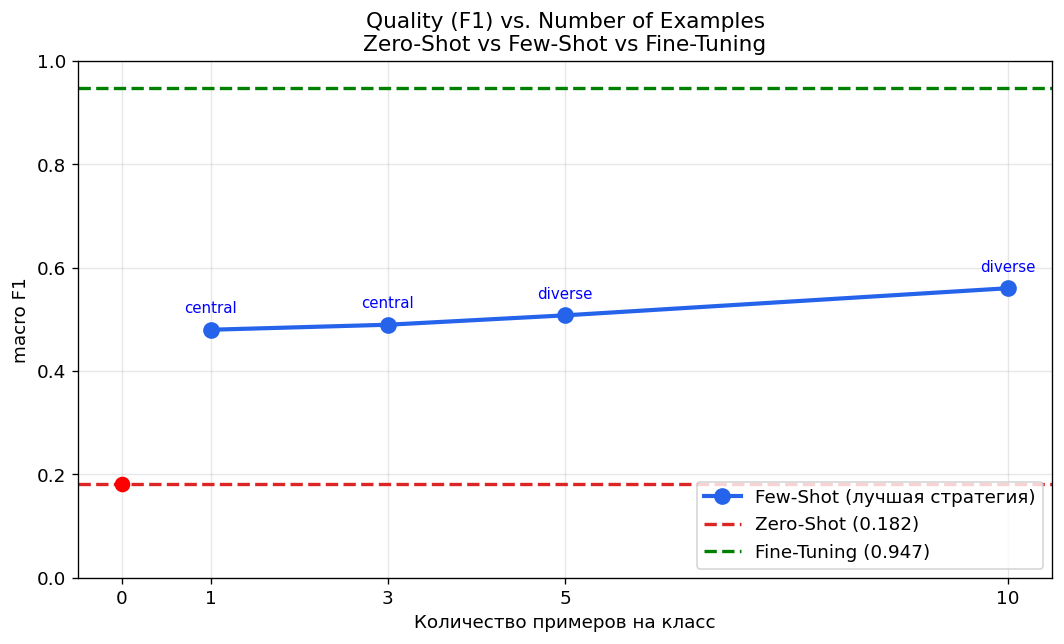

In [ ]:
# для линии Few-Shot берём лучшую стратегию на каждом n_shots
best_per_n = (fewshot
              .loc[fewshot.groupby("n_shots")["f1"].idxmax()]
              .sort_values("n_shots"))

fig, ax = plt.subplots(figsize=(9, 5.5))

# Few-Shot: кривая
ax.plot(best_per_n["n_shots"], best_per_n["f1"],
        marker="o", linewidth=2.5, markersize=9,
        color="#2563eb", label="Few-Shot (лучшая стратегия)", zorder=3)
# подпись стратегии-победителя у каждой точки
for _, r in best_per_n.iterrows():
    ax.annotate(r["strategy"], (r["n_shots"], r["f1"]),
                textcoords="offset points", xytext=(0, 10),
                ha="center", fontsize=9, color='blue')

# Zero-Shot: горизонтальная линия
if not np.isnan(zeroshot_f1):
    ax.axhline(zeroshot_f1, color="#dc2626", linestyle="--", linewidth=2,
               label=f"Zero-Shot ({zeroshot_f1:.3f})")
    # точка на оси x = 0
    ax.scatter([0], [zeroshot_f1], color='red', s=70, zorder=3)

# Fine-Tuning: горизонтальная линия
if not np.isnan(finetuning_f1):
    ax.axhline(finetuning_f1, color='green', linestyle="--", linewidth=2,
               label=f"Fine-Tuning ({finetuning_f1:.3f})")

ax.set_xlabel("Количество примеров на класс")
ax.set_ylabel("macro F1")
ax.set_title("Quality (F1) vs. Number of Examples\nZero-Shot vs Few-Shot vs Fine-Tuning",
             fontsize=13)
all_n = sorted(fewshot["n_shots"].unique())
ax.set_xticks([0] + all_n)
ax.set_ylim(0, 1.0)
ax.grid(alpha=0.3)
ax.legend(loc="lower right")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/exp03_f1_vs_examples.png", bbox_inches="tight")
plt.show()

In [23]:
best_row = fewshot.loc[fewshot["f1"].idxmax()]

print(f"Лучшая комбинация: {best_row['strategy']} / {best_row['n_shots']}-shot")
print(f"  F1 = {best_row['f1']:.4f}, Accuracy = {best_row['accuracy']:.4f}")


delta = best_row["f1"] - zeroshot_f1
print(f"\nЛучший Few-Shot против Zero-Shot: {delta:+.4f} F1")
gap = finetuning_f1 - best_row["f1"]
print(f"Отставание лучшего Few-Shot от Fine-Tuning: {gap:.4f} F1")

# растёт ли качество с числом примеров
trend = best_per_n.sort_values("n_shots")
print(f"\nРост F1 с {trend['n_shots'].iloc[0]} до {trend['n_shots'].iloc[-1]} примеров: "
      f"{trend['f1'].iloc[0]:.4f} -> {trend['f1'].iloc[-1]:.4f} "
      f"({trend['f1'].iloc[-1] - trend['f1'].iloc[0]:+.4f})")

Лучшая комбинация: diverse / 10-shot
  F1 = 0.5600, Accuracy = 0.5282

Лучший Few-Shot против Zero-Shot: +0.3784 F1
Отставание лучшего Few-Shot от Fine-Tuning: 0.3865 F1

Рост F1 с 1 до 10 примеров: 0.4797 -> 0.5600 (+0.0804)
